# Supermarket Sales Analysis

**Author:** Ansh_Srivastava  
**Project:** Supermarket_Sales_Analysis  
**Domain:** Data Analytics / Exploratory Data Analysis

## Project Overview
This notebook analyzes a supermarket transaction dataset to understand sales performance, customer behavior, product-line performance, payment preferences, and the relationship between quantity purchased and transaction value.

The notebook is designed to run from a clean environment. It downloads the dataset from a public CSV source and performs data loading, cleaning, feature engineering, KPI calculation, exploratory analysis, visualization, correlation analysis, and business insight generation.

**Dataset source:** https://github.com/Ansh-Srivastava01/Supermarket-Sales-Analysis/blob/main/supermarket_sales.csv


In [1]:
# Install only if your environment does not already contain the libraries.
# !pip install pandas numpy matplotlib seaborn jupyter


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_URL = "https://github.com/Ansh-Srivastava01/Supermarket-Sales-Analysis/blob/main/supermarket_sales.csv"
LOCAL_FILE = Path("supermarket_sales.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# Load dataset. If supermarket_sales.csv is already in the project folder,
# the local copy is used; otherwise the public CSV URL is used.

if LOCAL_FILE.exists():
    df = pd.read_csv(LOCAL_FILE)
    print("Loaded local dataset:", LOCAL_FILE.resolve())
else:
    df = pd.read_csv(DATA_URL)
    print("Loaded dataset from public URL.")

df.head()


Loaded local dataset: /mnt/data/final_run/supermarket_sales.csv


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
print("Shape:", df.shape)
display(df.info())
print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (1000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross m

None


Missing values:


,missing
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0



Duplicate rows: 0


In [5]:
# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

# Convert date/time fields
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Feature engineering
df["month"] = df["date"].dt.month_name()
df["month_num"] = df["date"].dt.month
df["weekday"] = df["date"].dt.day_name()
df["weekday_num"] = df["date"].dt.weekday
df["hour"] = df["time"].dt.hour

# Useful derived metric
df["revenue_per_item"] = df["total"] / df["quantity"]

print("Cleaning and feature engineering complete.")
df.head()


Cleaning and feature engineering complete.


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,month,month_num,weekday,weekday_num,hour,revenue_per_item
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-09-23 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,January,1,Saturday,5,13,78.4245
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-09-23 10:29:00,Cash,76.40,4.761905,3.8200,9.6,March,3,Friday,4,10,16.0440
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2026-09-23 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,March,3,Sunday,6,13,48.6465
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2026-09-23 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,January,1,Sunday,6,20,61.1310
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-09-23 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,February,2,Friday,4,10,90.6255


In [6]:
# KPI summary
kpis = pd.Series({
    "Transactions": len(df),
    "Total Sales": df["total"].sum(),
    "Gross Income": df["gross_income"].sum(),
    "Units Sold": df["quantity"].sum(),
    "Average Transaction": df["total"].mean(),
    "Average Rating": df["rating"].mean()
})
display(kpis.to_frame("Value"))


,Value
Transactions,1000.000000
Total Sales,322966.749000
Gross Income,15379.369000
Units Sold,5510.000000
Average Transaction,322.966749
Average Rating,6.972700


,branch,city,total
2,C,Naypyitaw,110568.7065
0,A,Yangon,106200.3705
1,B,Mandalay,106197.6720


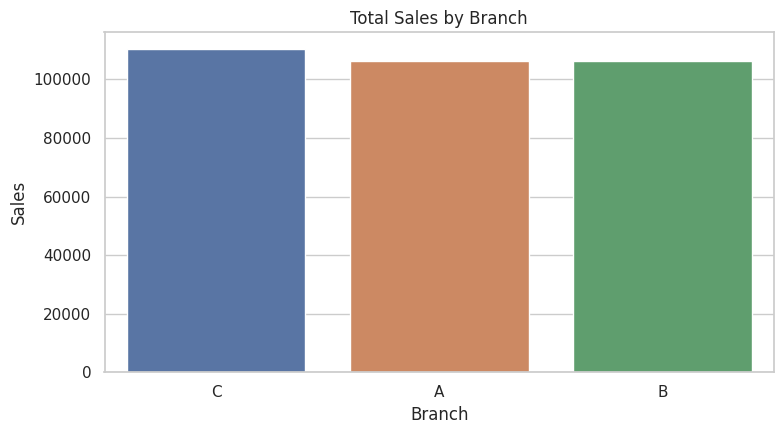

In [7]:
# Sales by branch/city
branch_sales = (
    df.groupby(["branch", "city"], as_index=False)["total"]
      .sum()
      .sort_values("total", ascending=False)
)
display(branch_sales)

plt.figure(figsize=(8,4.5))
sns.barplot(data=branch_sales, x="branch", y="total", hue="branch", legend=False)
plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sales_by_branch.png", dpi=180)
plt.show()


,product_line,total
2,Food and beverages,56144.8440
5,Sports and travel,55122.8265
0,Electronic accessories,54337.5315
1,Fashion accessories,54305.8950
4,Home and lifestyle,53861.9130
3,Health and beauty,49193.7390


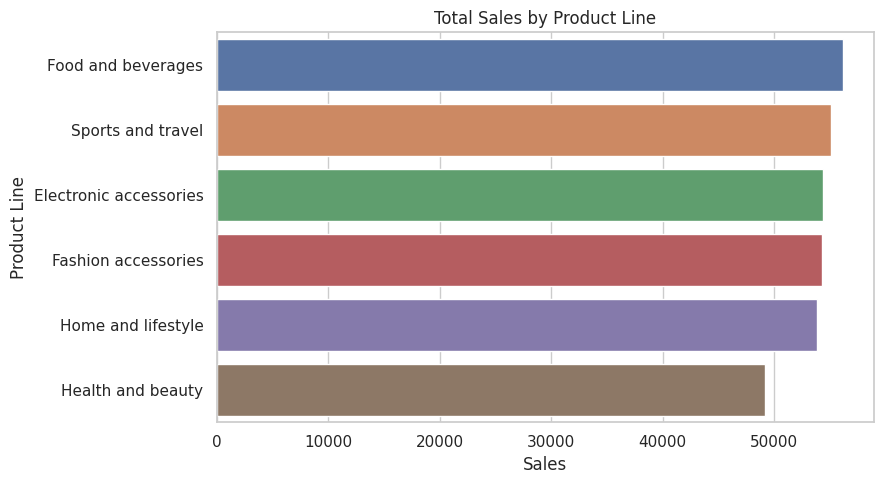

In [8]:
# Sales by product line
product_sales_df = (
    df.groupby("product_line", as_index=False)["total"]
      .sum()
      .sort_values("total", ascending=False)
)
display(product_sales_df)

plt.figure(figsize=(9,5))
sns.barplot(data=product_sales_df, y="product_line", x="total", hue="product_line", legend=False)
plt.title("Total Sales by Product Line")
plt.xlabel("Sales")
plt.ylabel("Product Line")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sales_by_product_line.png", dpi=180)
plt.show()


,transactions,revenue
payment,,
Cash,344,112206.570
Ewallet,345,109993.107
Credit card,311,100767.072


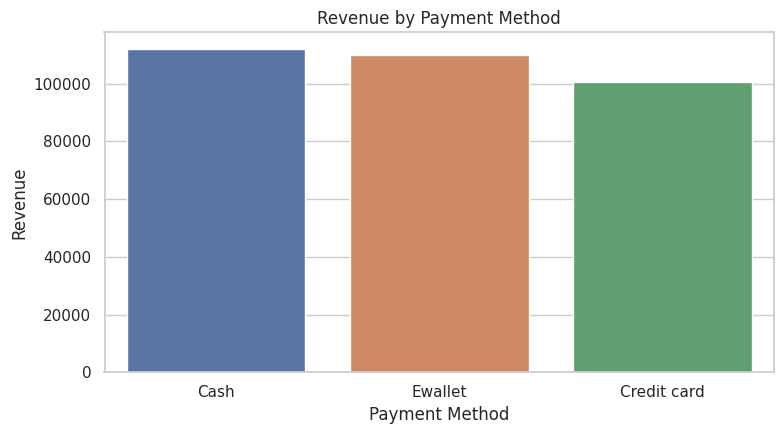

In [9]:
# Payment method analysis
payment = (
    df.groupby("payment")
      .agg(transactions=("invoice_id", "count"), revenue=("total", "sum"))
      .sort_values("revenue", ascending=False)
)
display(payment)

plt.figure(figsize=(8,4.5))
sns.barplot(x=payment.index, y=payment["revenue"].values, hue=payment.index, legend=False)
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "revenue_by_payment.png", dpi=180)
plt.show()


,revenue
customer_type,
Member,164223.444
Normal,158743.305


,revenue
gender,
Female,167882.925
Male,155083.824


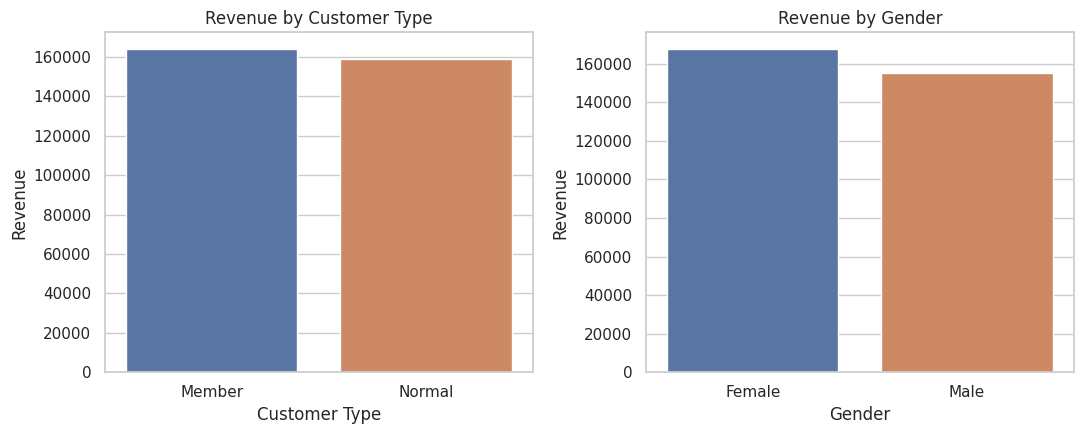

In [10]:
# Customer type and gender analysis
customer_sales = df.groupby("customer_type")["total"].sum().sort_values(ascending=False)
gender_sales = df.groupby("gender")["total"].sum().sort_values(ascending=False)

display(customer_sales.to_frame("revenue"))
display(gender_sales.to_frame("revenue"))

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
sns.barplot(x=customer_sales.index, y=customer_sales.values, hue=customer_sales.index, legend=False, ax=axes[0])
axes[0].set_title("Revenue by Customer Type")
axes[0].set_xlabel("Customer Type")
axes[0].set_ylabel("Revenue")

sns.barplot(x=gender_sales.index, y=gender_sales.values, hue=gender_sales.index, legend=False, ax=axes[1])
axes[1].set_title("Revenue by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "customer_gender_revenue.png", dpi=180)
plt.show()


,month_num,month,total
0,1,January,116291.868
1,2,February,97219.374
2,3,March,109455.507


,weekday_num,weekday,total
0,0,Monday,37899.0780
1,1,Tuesday,51482.2455
2,2,Wednesday,43731.1350
3,3,Thursday,45349.2480
4,4,Friday,43926.3405
5,5,Saturday,56120.8095
6,6,Sunday,44457.8925


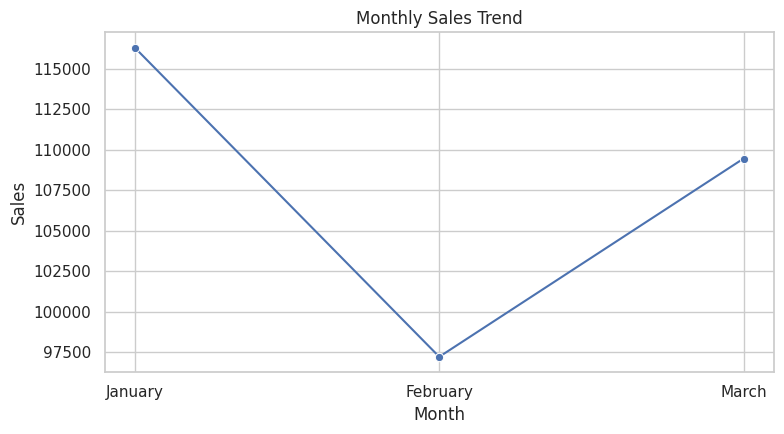

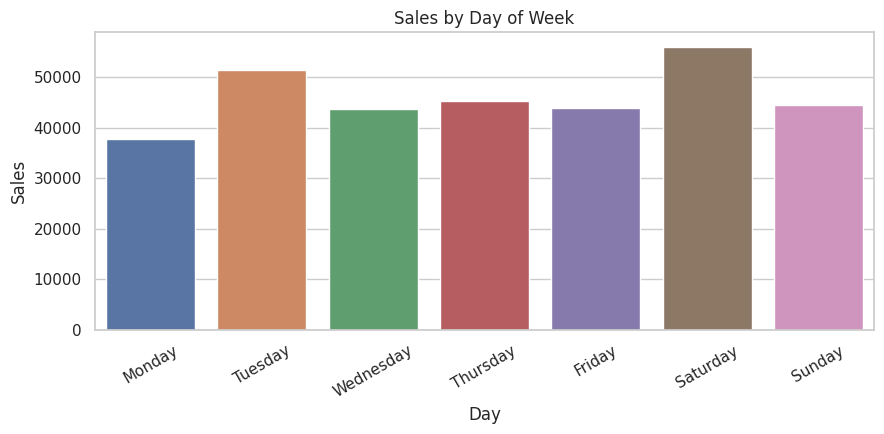

In [11]:
# Monthly and weekday trends
monthly_sales = (
    df.groupby(["month_num", "month"], as_index=False)["total"]
      .sum()
      .sort_values("month_num")
)
weekday_sales = (
    df.groupby(["weekday_num", "weekday"], as_index=False)["total"]
      .sum()
      .sort_values("weekday_num")
)

display(monthly_sales)
display(weekday_sales)

plt.figure(figsize=(8,4.5))
sns.lineplot(data=monthly_sales, x="month", y="total", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_sales.png", dpi=180)
plt.show()

plt.figure(figsize=(9,4.5))
sns.barplot(data=weekday_sales, x="weekday", y="total", hue="weekday", legend=False)
plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weekday_sales.png", dpi=180)
plt.show()


Pearson correlation between Quantity and Total Sales: 0.7055


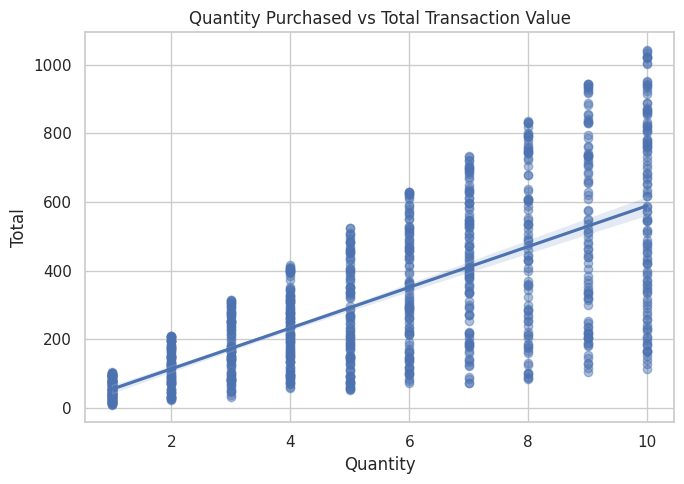

In [12]:
# Quantity vs Total sales
corr = df["quantity"].corr(df["total"])
print(f"Pearson correlation between Quantity and Total Sales: {corr:.4f}")

plt.figure(figsize=(7,5))
sns.regplot(data=df, x="quantity", y="total", scatter_kws={"alpha":0.45}, line_kws={})
plt.title("Quantity Purchased vs Total Transaction Value")
plt.xlabel("Quantity")
plt.ylabel("Total")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quantity_vs_total.png", dpi=180)
plt.show()


,average_rating
product_line,
Food and beverages,7.113218
Fashion accessories,7.029213
Health and beauty,7.003289
Electronic accessories,6.924706
Sports and travel,6.916265
Home and lifestyle,6.837500


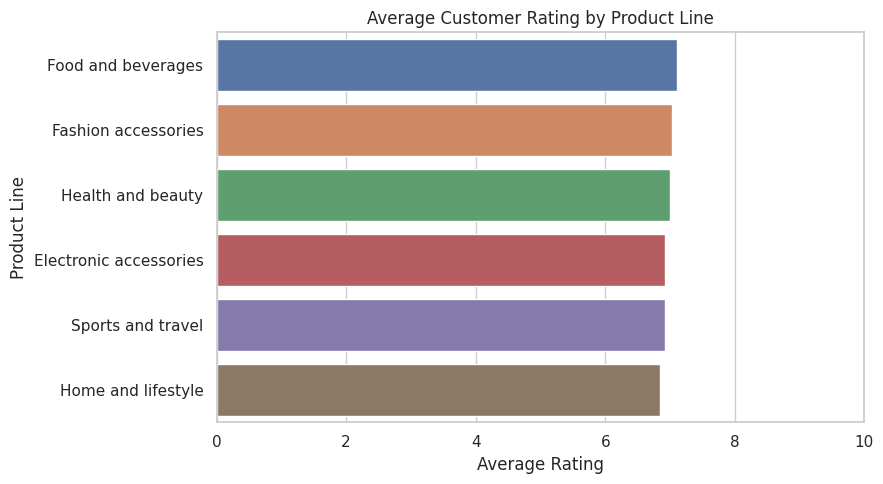

In [13]:
# Rating analysis by product line
rating_by_product = (
    df.groupby("product_line")["rating"]
      .mean()
      .sort_values(ascending=False)
)
display(rating_by_product.to_frame("average_rating"))

plt.figure(figsize=(9,5))
sns.barplot(x=rating_by_product.values, y=rating_by_product.index, hue=rating_by_product.index, legend=False)
plt.title("Average Customer Rating by Product Line")
plt.xlabel("Average Rating")
plt.ylabel("Product Line")
plt.xlim(0, 10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rating_by_product_line.png", dpi=180)
plt.show()


In [14]:
# Automatic insight summary
top_city = branch_sales.iloc[0]["city"]
top_branch_sales = branch_sales.iloc[0]["total"]
top_product = product_sales_df.iloc[0]["product_line"]
top_product_sales = product_sales_df.iloc[0]["total"]
top_payment = payment.index[0]
top_payment_revenue = payment.iloc[0]["revenue"]
top_customer_type = customer_sales.index[0]

print("KEY INSIGHTS")
print(f"1. Highest-sales city/branch: {top_city} / Branch {branch_sales.iloc[0]['branch']} (${top_branch_sales:,.2f}).")
print(f"2. Highest-sales product line: {top_product} (${top_product_sales:,.2f}).")
print(f"3. Highest-revenue payment method: {top_payment} (${top_payment_revenue:,.2f}).")
print(f"4. Higher-revenue customer segment: {top_customer_type}.")
print(f"5. Quantity-to-total correlation: {corr:.4f}, indicating a positive linear association in this dataset.")


KEY INSIGHTS
1. Highest-sales city/branch: Naypyitaw / Branch C ($110,568.71).
2. Highest-sales product line: Food and beverages ($56,144.84).
3. Highest-revenue payment method: Cash ($112,206.57).
4. Higher-revenue customer segment: Member.
5. Quantity-to-total correlation: 0.7055, indicating a positive linear association in this dataset.


## Conclusion

The analysis converts raw supermarket transactions into a compact set of business metrics and visual insights. The notebook identifies branch/city performance, product-line contribution, payment behavior, customer-type contribution, customer ratings, time-based sales patterns, and the relationship between quantity and transaction value.

### Limitations
- The dataset covers only three months.
- The analysis is descriptive and does not establish causal relationships.
- Product-level SKU information is not available, so individual product recommendations cannot be made.
- The dataset is historical and should not be treated as a current market forecast.

### Suggested Extensions
1. Add forecasting for future daily/weekly sales.
2. Build a Power BI or Streamlit dashboard.
3. Segment customers using clustering.
4. Add promotion/discount fields to evaluate campaign effectiveness.
5. Connect the pipeline to a live database.
